In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)

In [4]:
KAGGLE_PATH = '/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv'
LOCAL_PATH  = '/content/tesla_deliveries_dataset_2015_2025.csv'

if os.path.exists(KAGGLE_PATH):
    raw = pd.read_csv(KAGGLE_PATH)
else:
    raw = pd.read_csv(LOCAL_PATH)

print('Shape:', raw.shape)
raw.head()

Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [5]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [6]:
raw.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [7]:
print('Missing values:')
print(raw.isnull().sum())
print('\nDuplicate rows:', raw.duplicated().sum())

Missing values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate rows: 0


In [8]:
df = raw.copy()

num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include='object').columns

num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

if len(cat_cols) > 0:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print('Cleaned shape:', df.shape)

Cleaned shape: (2640, 12)


In [9]:
def iqr_cap(data, col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    data[col] = data[col].clip(lower=q1 - 1.5*iqr, upper=q3 + 1.5*iqr)
    return data

for col in ['Production_Units', 'Avg_Price_USD', 'Estimated_Deliveries']:
    if col in df.columns:
        df = iqr_cap(df, col)

print('Outlier capping applied.')

Outlier capping applied.


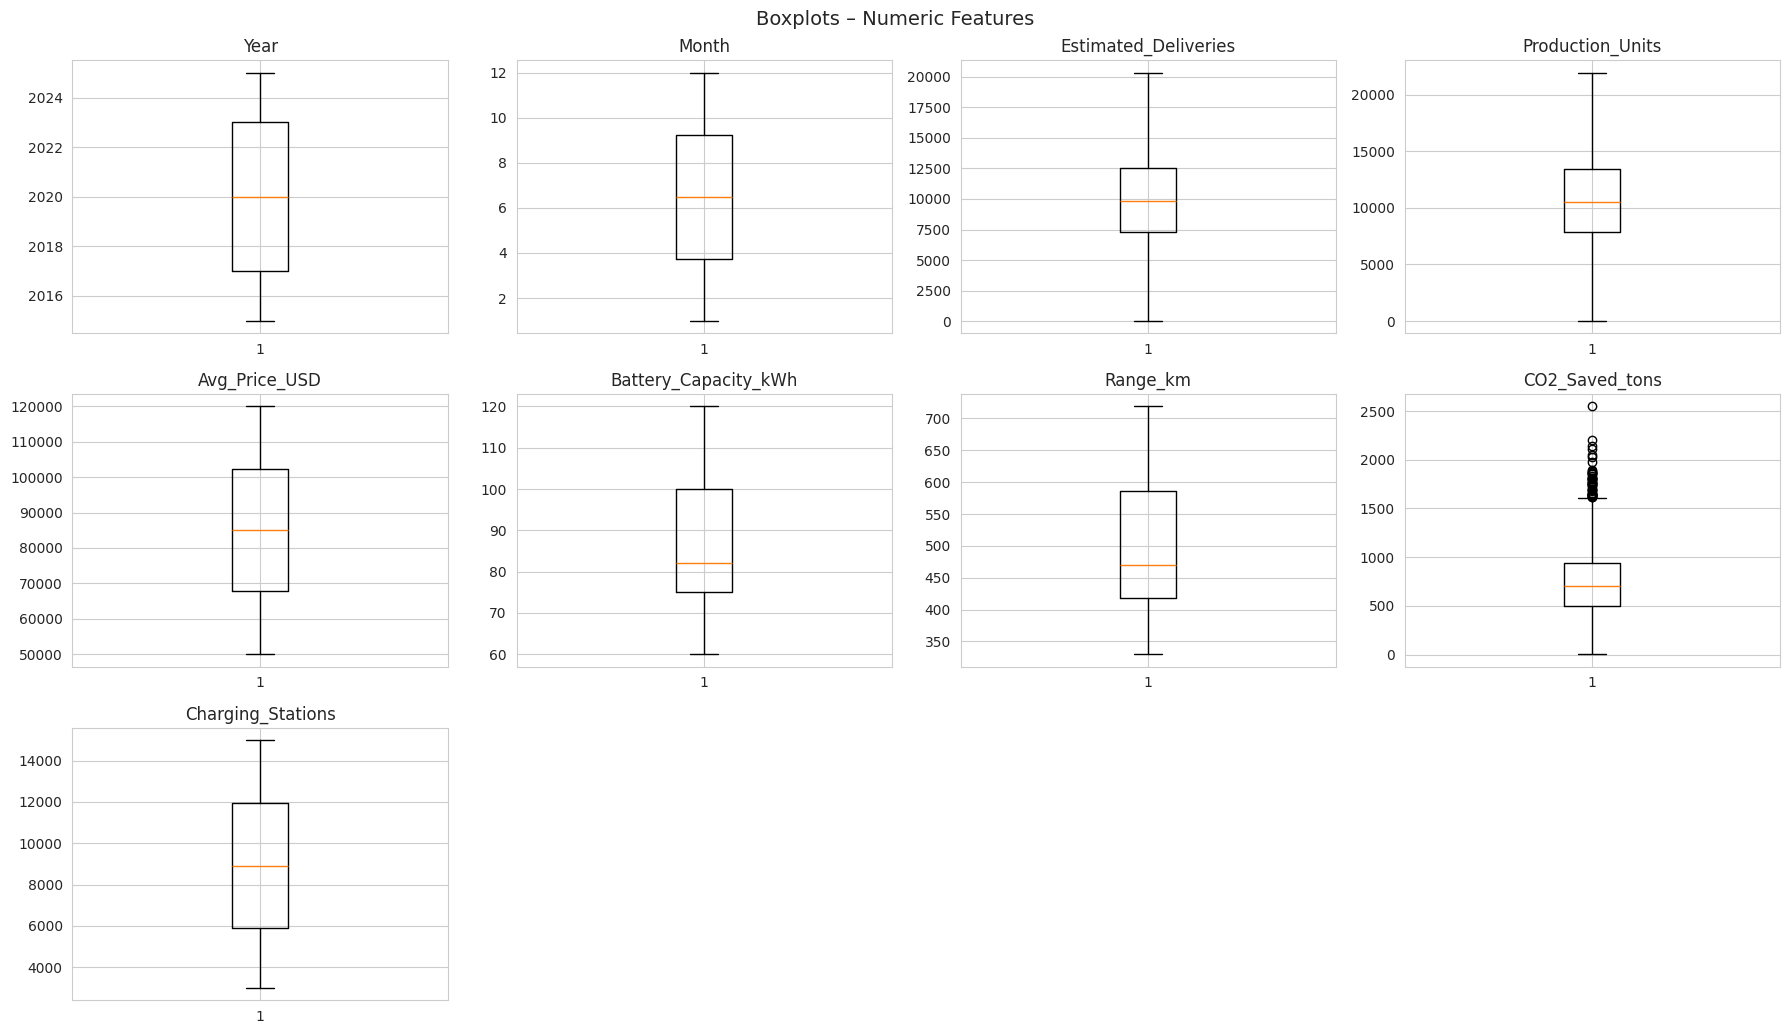

In [10]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

n = len(numeric_cols)
cols_per_row = 4
rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(18, rows*3.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Boxplots – Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

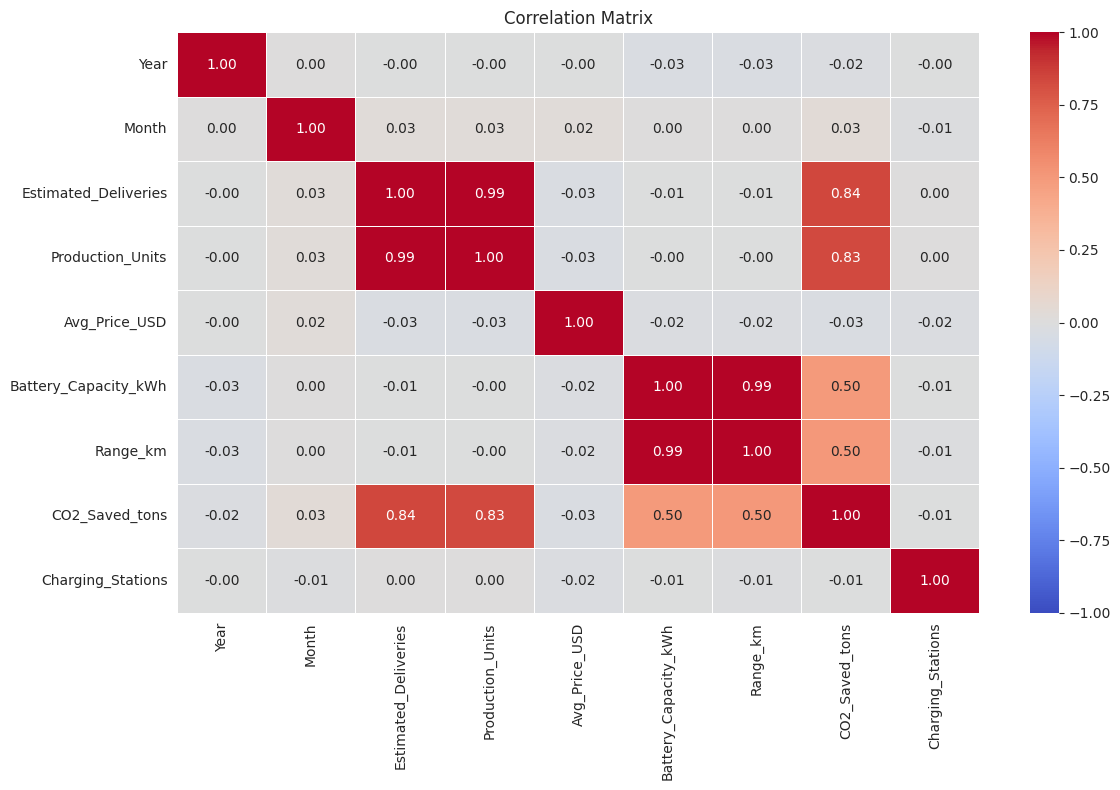

In [11]:
plt.figure(figsize=(12, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.4)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

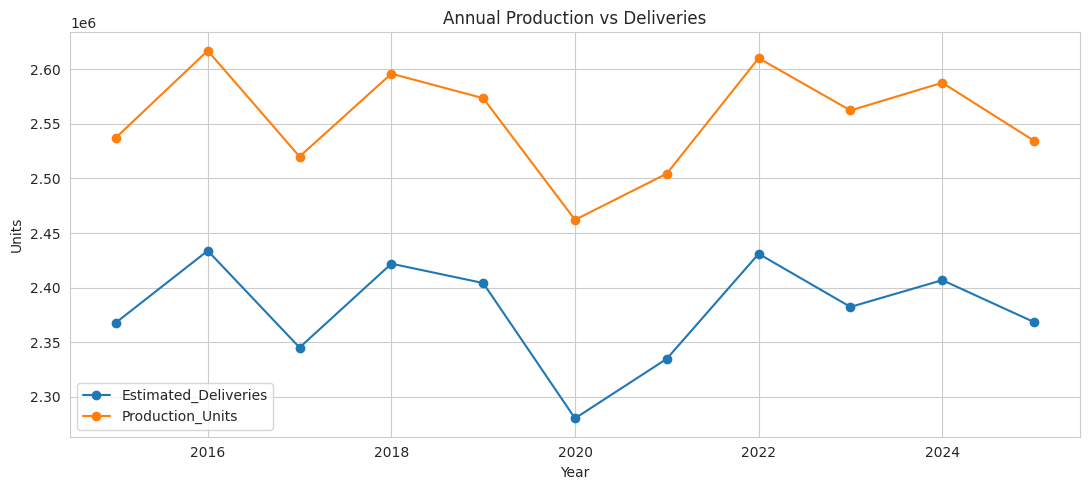

In [12]:
if 'Year' in df.columns:
    yearly = df.groupby('Year')[['Estimated_Deliveries', 'Production_Units']].sum()
    yearly.plot(marker='o', figsize=(11, 5))
    plt.title('Annual Production vs Deliveries')
    plt.ylabel('Units')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

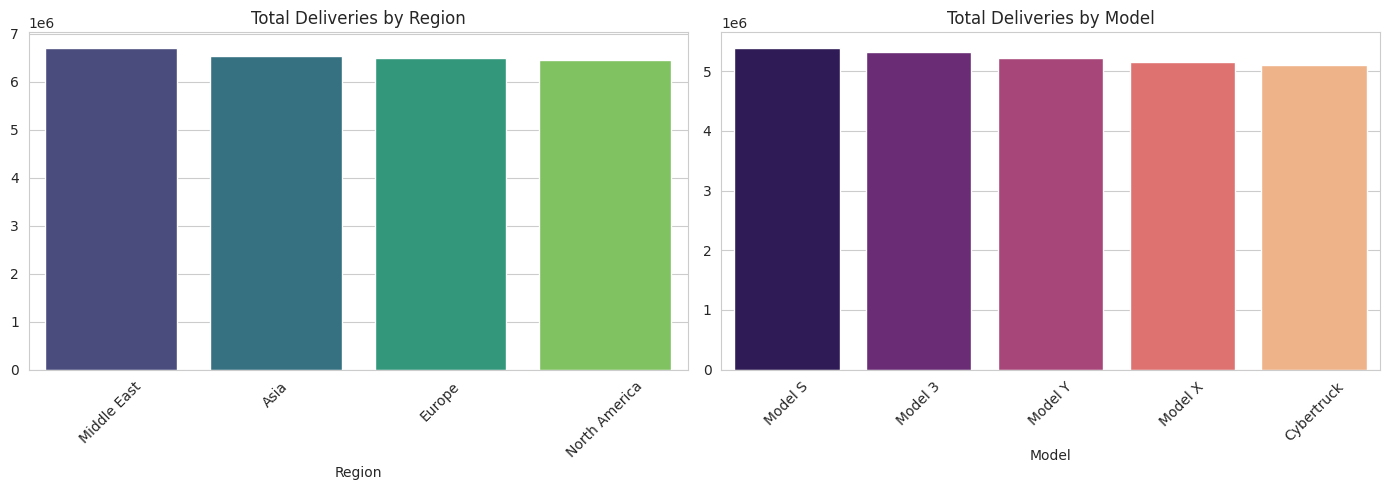

In [13]:
if 'Region' in df.columns and df['Region'].dtype == 'object':
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    region_data = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values(ascending=False)
    sns.barplot(x=region_data.index, y=region_data.values, ax=axes[0], palette='viridis')
    axes[0].set_title('Total Deliveries by Region')
    axes[0].tick_params(axis='x', rotation=45)

    if 'Model' in df.columns:
        model_data = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending=False)
        sns.barplot(x=model_data.index, y=model_data.values, ax=axes[1], palette='magma')
        axes[1].set_title('Total Deliveries by Model')
        axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

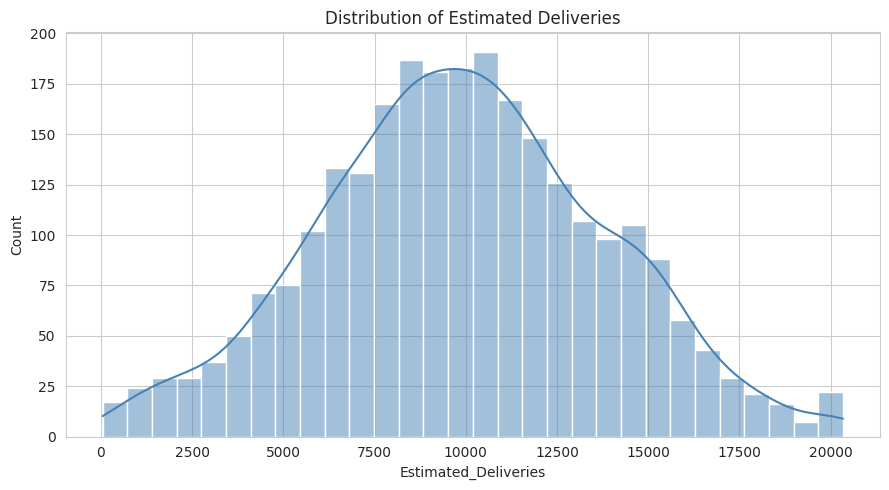

In [14]:
plt.figure(figsize=(9, 5))
sns.histplot(df['Estimated_Deliveries'], kde=True, bins=30, color='steelblue')
plt.title('Distribution of Estimated Deliveries')
plt.tight_layout()
plt.show()

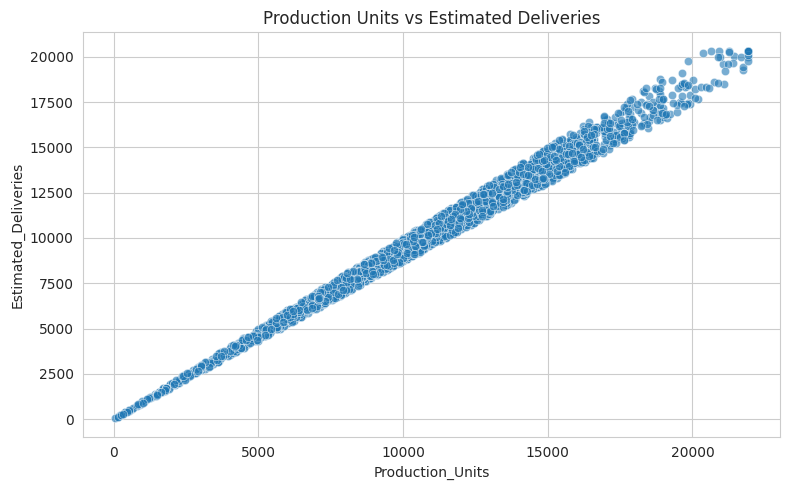

In [15]:
if 'Production_Units' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=df['Production_Units'], y=df['Estimated_Deliveries'], alpha=0.6)
    plt.title('Production Units vs Estimated Deliveries')
    plt.tight_layout()
    plt.show()

In [16]:
df = df.sort_values(['Year', 'Month']).reset_index(drop=True)

df['Date'] = pd.to_datetime(
    df['Year'].astype(int).astype(str) + '-' +
    df['Month'].astype(int).astype(str) + '-01'
)

df['Quarter']       = ((df['Month'] - 1) // 3) + 1
df['Lag_1']         = df['Estimated_Deliveries'].shift(1)
df['Lag_2']         = df['Estimated_Deliveries'].shift(2)
df['Rolling_Mean_3']= df['Estimated_Deliveries'].rolling(3).mean()
df['Rolling_Std_3'] = df['Estimated_Deliveries'].rolling(3).std()
df['Inventory']     = df['Production_Units'] - df['Estimated_Deliveries']
df['Efficiency']    = df['Estimated_Deliveries'] / df['Production_Units'].replace(0, np.nan)

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print('Shape after feature engineering:', df.shape)

Shape after feature engineering: (2638, 20)


In [17]:
cat_cols_to_encode = [c for c in ['Region', 'Model', 'Source_Type'] if c in df.columns and df[c].dtype == 'object']

encoders = {}
for col in cat_cols_to_encode:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

feature_cols = [
    'Year', 'Month', 'Quarter', 'Production_Units',
    'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
    'CO2_Saved_tons', 'Lag_1', 'Lag_2',
    'Rolling_Mean_3', 'Rolling_Std_3', 'Inventory', 'Efficiency'
]

for col in ['Region', 'Model', 'Source_Type', 'Charging_Stations']:
    if col in df.columns:
        feature_cols.append(col)

feature_cols = [c for c in feature_cols if c in df.columns]

X = df[feature_cols]
y = df['Estimated_Deliveries']

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print('Train size:', X_train.shape, '| Test size:', X_test.shape)

Train size: (2110, 18) | Test size: (528, 18)


In [18]:
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

In [19]:
def evaluate_model(model, Xtr, ytr, Xte, yte, name):
    pred_tr = model.predict(Xtr)
    pred_te = model.predict(Xte)

    r2_tr = r2_score(ytr, pred_tr)
    r2_te = r2_score(yte, pred_te)
    mae   = mean_absolute_error(yte, pred_te)
    rmse  = np.sqrt(mean_squared_error(yte, pred_te))

    print(f'\n── {name} ──')
    print(f'  Train R²: {r2_tr:.4f} | Test R²: {r2_te:.4f}')
    print(f'  MAE: {mae:.4f}   RMSE: {rmse:.4f}')

    if r2_tr - r2_te > 0.15:
        print('  [Diagnostic] Possible overfitting (high variance).')
    elif r2_tr < 0.6 and r2_te < 0.6:
        print('  [Diagnostic] Possible underfitting (high bias).')
    else:
        print('  [Diagnostic] Reasonable fit.')

    return {'Model': name, 'R2_Train': r2_tr, 'R2_Test': r2_te, 'MAE': mae, 'RMSE': rmse}, pred_te

In [20]:
results_list = []
predictions  = {}

lr = LinearRegression()
lr.fit(X_train_scaled, y_train_scaled)
r, p = evaluate_model(lr, X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, 'Linear Regression')
results_list.append(r); predictions['Linear Regression'] = p

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train_scaled)
r, p = evaluate_model(ridge, X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, 'Ridge')
results_list.append(r); predictions['Ridge'] = p

lasso = Lasso(alpha=0.001)
lasso.fit(X_train_scaled, y_train_scaled)
r, p = evaluate_model(lasso, X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, 'Lasso')
results_list.append(r); predictions['Lasso'] = p

rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1))
])
rf_pipe.fit(X_train, y_train_scaled)
r, p = evaluate_model(rf_pipe, X_train, y_train_scaled, X_test, y_test_scaled, 'Random Forest')
results_list.append(r); predictions['Random Forest'] = p

gb_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GradientBoostingRegressor(n_estimators=150, learning_rate=0.08, max_depth=4, random_state=42))
])
gb_pipe.fit(X_train, y_train_scaled)
r, p = evaluate_model(gb_pipe, X_train, y_train_scaled, X_test, y_test_scaled, 'Gradient Boosting')
results_list.append(r); predictions['Gradient Boosting'] = p


── Linear Regression ──
  Train R²: 1.0000 | Test R²: 1.0000
  MAE: 0.0000   RMSE: 0.0000
  [Diagnostic] Reasonable fit.

── Ridge ──
  Train R²: 1.0000 | Test R²: 1.0000
  MAE: 0.0002   RMSE: 0.0004
  [Diagnostic] Reasonable fit.

── Lasso ──
  Train R²: 0.9997 | Test R²: 0.9996
  MAE: 0.0024   RMSE: 0.0034
  [Diagnostic] Reasonable fit.

── Random Forest ──
  Train R²: 0.9999 | Test R²: 0.9994
  MAE: 0.0031   RMSE: 0.0045
  [Diagnostic] Reasonable fit.

── Gradient Boosting ──
  Train R²: 0.9999 | Test R²: 0.9997
  MAE: 0.0025   RMSE: 0.0033
  [Diagnostic] Reasonable fit.


,Model,R2_Train,R2_Test,MAE,RMSE
0,Linear Regression,1.000000,1.000000,1.261486e-16,1.588807e-16
1,Ridge,0.999996,0.999996,2.492158e-04,3.667810e-04
2,Gradient Boosting,0.999915,0.999662,2.502063e-03,3.322946e-03
3,Lasso,0.999704,0.999647,2.389765e-03,3.395049e-03
4,Random Forest,0.999911,0.999391,3.094781e-03,4.462154e-03


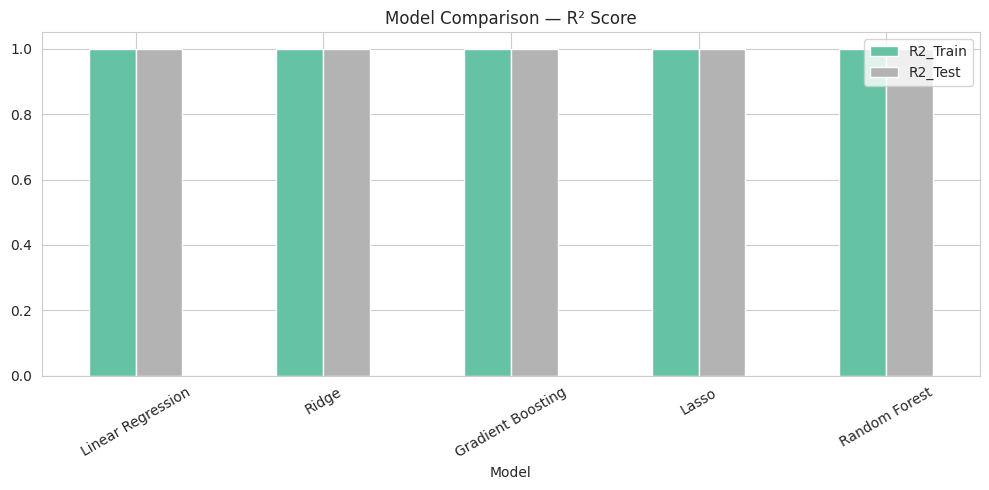

In [21]:
results_df = pd.DataFrame(results_list).sort_values('R2_Test', ascending=False).reset_index(drop=True)
display(results_df)

results_df.set_index('Model')[['R2_Train', 'R2_Test']].plot(kind='bar', figsize=(10, 5), colormap='Set2')
plt.title('Model Comparison — R² Score')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [22]:
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
gs = GridSearchCV(Ridge(), param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
gs.fit(X_train_scaled, y_train_scaled)

print('Best alpha:', gs.best_params_['alpha'])

best_ridge = gs.best_estimator_
r, _ = evaluate_model(best_ridge, X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, 'Ridge (Tuned)')

Best alpha: 0.001

── Ridge (Tuned) ──
  Train R²: 1.0000 | Test R²: 1.0000
  MAE: 0.0000   RMSE: 0.0000
  [Diagnostic] Reasonable fit.


In [23]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_ridge = cross_val_score(best_ridge, X_train_scaled, y_train_scaled, cv=kf, scoring='r2')
cv_rf    = cross_val_score(rf_pipe,    X_train,        y_train_scaled, cv=kf, scoring='r2')

print(f'Ridge CV R²   : {cv_ridge.mean():.4f} ± {cv_ridge.std():.4f}')
print(f'RandomForest CV R²: {cv_rf.mean():.4f} ± {cv_rf.std():.4f}')

Ridge CV R²   : 1.0000 ± 0.0000
RandomForest CV R²: 0.9991 ± 0.0002


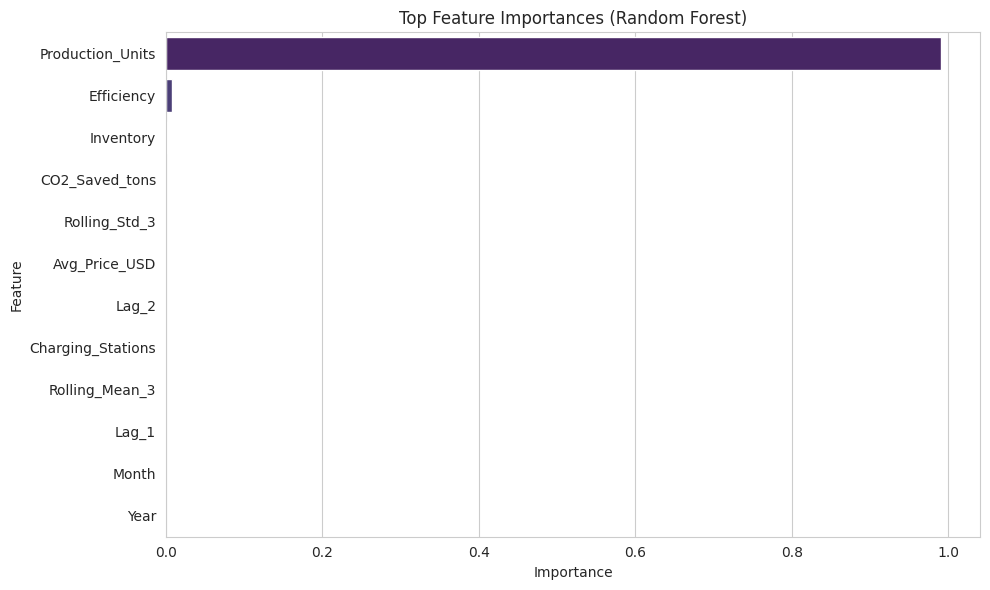

In [24]:
importances = rf_pipe.named_steps['model'].feature_importances_
imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=False).head(12)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=imp_df, palette='viridis')
plt.title('Top Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

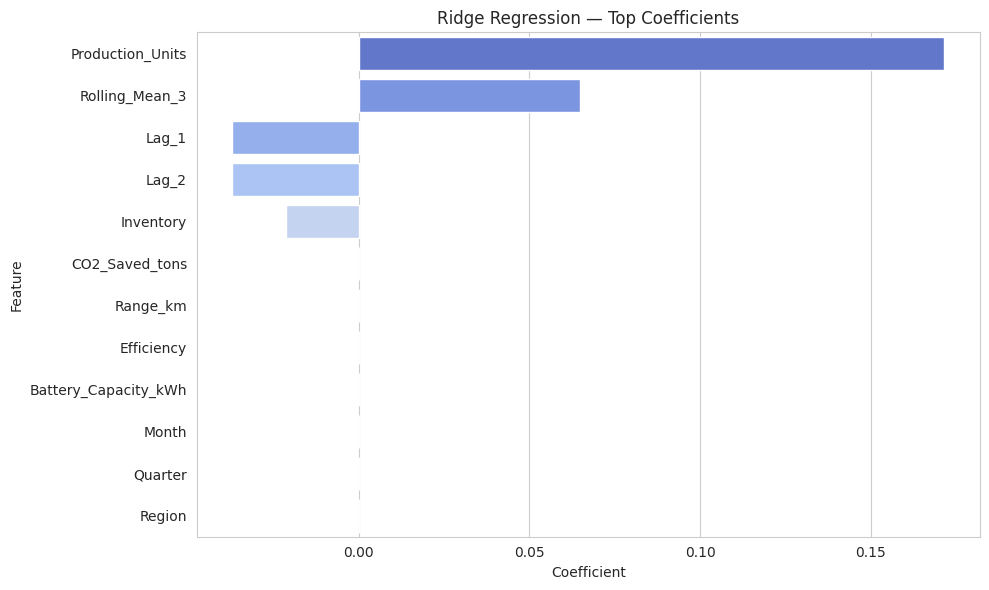

In [25]:
ridge_coef = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': best_ridge.coef_
}).reindex(pd.Series(best_ridge.coef_).abs().sort_values(ascending=False).index)

ridge_coef = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': best_ridge.coef_
})
ridge_coef['AbsCoef'] = ridge_coef['Coefficient'].abs()
ridge_coef = ridge_coef.sort_values('AbsCoef', ascending=False).head(12)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=ridge_coef, palette='coolwarm')
plt.title('Ridge Regression — Top Coefficients')
plt.tight_layout()
plt.show()

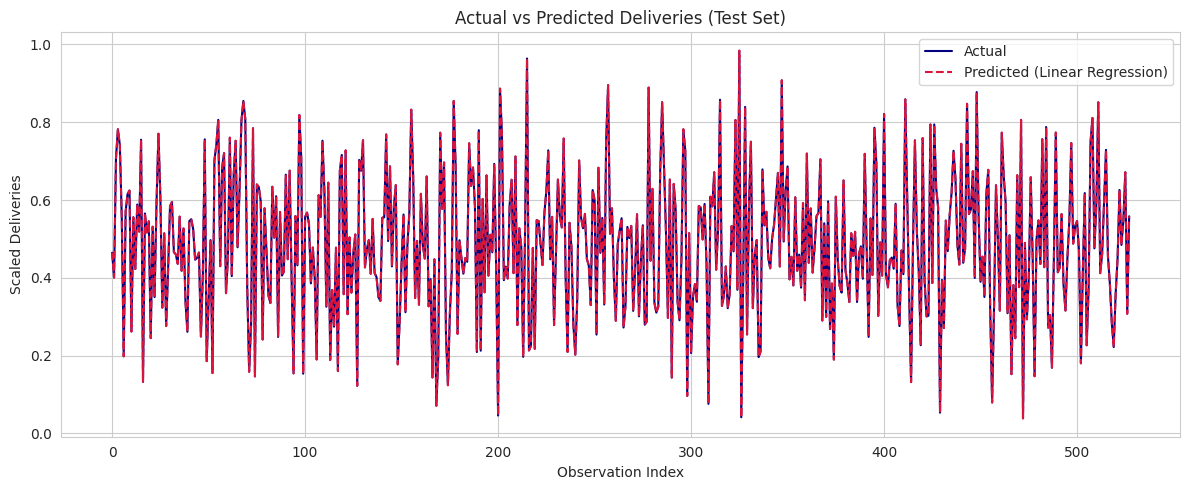

In [26]:
best_model_name = results_df.iloc[0]['Model']
best_pred = predictions.get(best_model_name)

plt.figure(figsize=(12, 5))
plt.plot(y_test_scaled, label='Actual', color='navy')
plt.plot(best_pred, label=f'Predicted ({best_model_name})', color='crimson', linestyle='--')
plt.title('Actual vs Predicted Deliveries (Test Set)')
plt.xlabel('Observation Index')
plt.ylabel('Scaled Deliveries')
plt.legend()
plt.tight_layout()
plt.show()

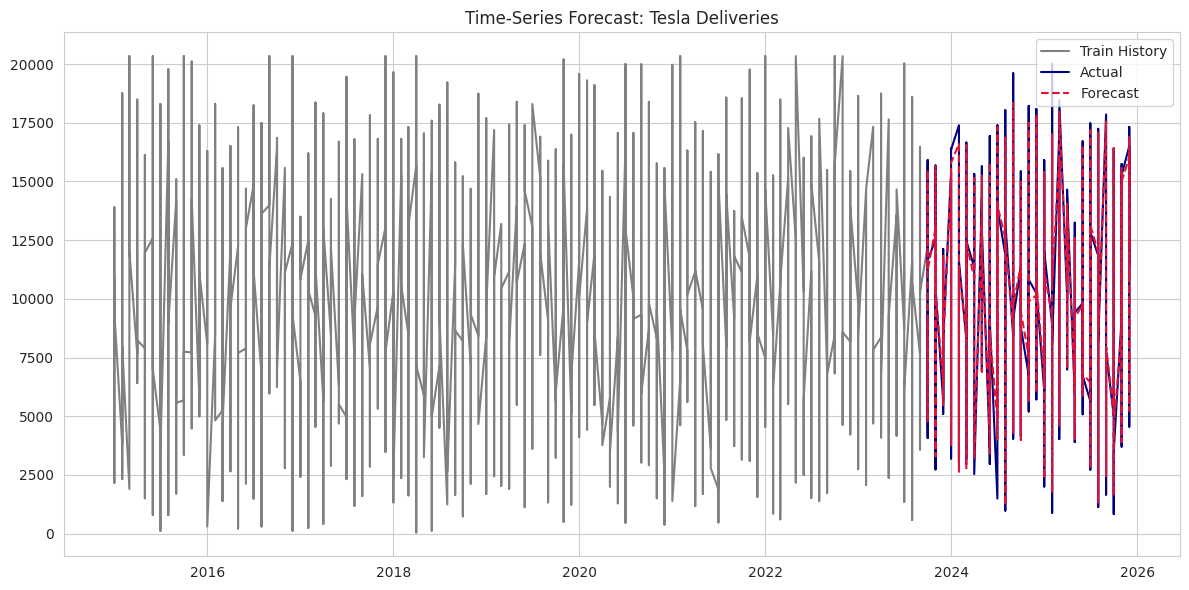

Time-Series Forecast R²: 0.9675


In [27]:
ts_df = df[['Date', 'Estimated_Deliveries', 'Lag_1', 'Lag_2', 'Rolling_Mean_3', 'Rolling_Std_3']].copy()
ts_df = ts_df.set_index('Date').sort_index()

ts_split = int(len(ts_df) * 0.8)
ts_train = ts_df.iloc[:ts_split]
ts_test  = ts_df.iloc[ts_split:]

ts_features = ['Lag_1', 'Lag_2', 'Rolling_Mean_3', 'Rolling_Std_3']

ts_model = RandomForestRegressor(n_estimators=150, random_state=42)
ts_model.fit(ts_train[ts_features], ts_train['Estimated_Deliveries'])

ts_preds = ts_model.predict(ts_test[ts_features])

plt.figure(figsize=(12, 6))
plt.plot(ts_train.index, ts_train['Estimated_Deliveries'], label='Train History', color='gray')
plt.plot(ts_test.index,  ts_test['Estimated_Deliveries'],  label='Actual',        color='navy')
plt.plot(ts_test.index,  ts_preds,                          label='Forecast',      color='crimson', linestyle='--')
plt.title('Time-Series Forecast: Tesla Deliveries')
plt.legend()
plt.tight_layout()
plt.show()

ts_r2 = r2_score(ts_test['Estimated_Deliveries'], ts_preds)
print(f'Time-Series Forecast R²: {ts_r2:.4f}')

,Period,Predicted_Deliveries
0,Q1 2026,8478.893333
1,Q2 2026,9900.040000
2,Q3 2026,8996.180000
3,Q4 2026,9599.260000


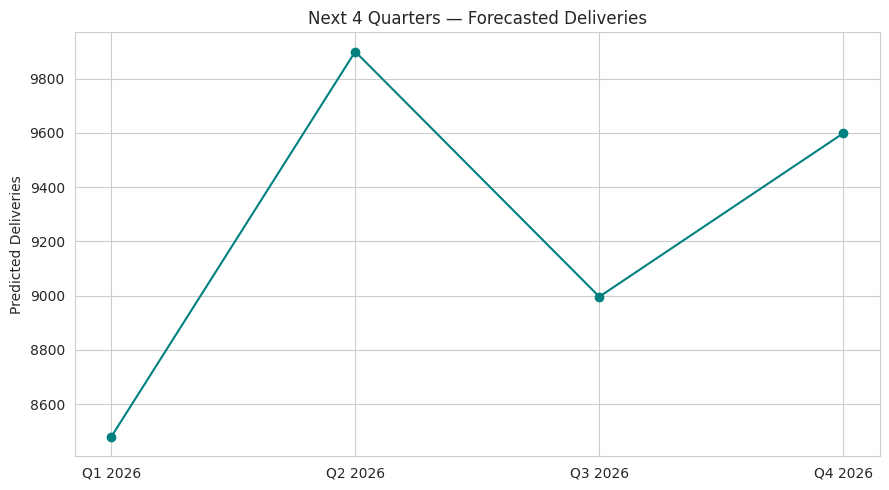

In [28]:
forecast_data = df.sort_values(['Year', 'Month']).copy()
lag1 = forecast_data['Estimated_Deliveries'].iloc[-1]
lag2 = forecast_data['Estimated_Deliveries'].iloc[-2]

cur_year  = int(forecast_data['Year'].iloc[-1])
cur_month = int(forecast_data['Month'].iloc[-1])

future = []
quarter_labels = []

for i in range(1, 5):
    cur_month += 3
    if cur_month > 12:
        cur_month -= 12
        cur_year  += 1

    rolling_mean = np.mean([lag1, lag2])
    rolling_std  = np.std([lag1, lag2])

    row_features = pd.DataFrame([{
        'Lag_1': lag1, 'Lag_2': lag2,
        'Rolling_Mean_3': rolling_mean, 'Rolling_Std_3': rolling_std
    }])

    pred_val = ts_model.predict(row_features)[0]
    future.append(pred_val)
    quarter_labels.append(f'Q{((cur_month-1)//3)+1} {cur_year}')

    lag2 = lag1
    lag1 = pred_val

forecast_df = pd.DataFrame({'Period': quarter_labels, 'Predicted_Deliveries': future})
display(forecast_df)

plt.figure(figsize=(9, 5))
plt.plot(forecast_df['Period'], forecast_df['Predicted_Deliveries'], marker='o', color='teal')
plt.title('Next 4 Quarters — Forecasted Deliveries')
plt.ylabel('Predicted Deliveries')
plt.grid(True)
plt.tight_layout()
plt.show()

In [29]:
joblib.dump(rf_pipe, 'tesla_delivery_model.pkl')
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')
print('Model and scalers saved.')

Model and scalers saved.
